# 🧩 实验 10：在 CartPole 上实现 REINFORCE

在之前的实验中，我们使用蒙特卡洛方法来估计价值函数，从而解决 CartPole 控制任务。我们将状态空间离散化，收集完整轨迹，计算回报，并使用这些回报来更新表格形式的 \(Q(s,a)\) 估计值。

在本实验中，我们将重新回到 CartPole 环境。不过这一次，我们不再估计价值函数，而是直接使用神经网络来学习一个**参数化策略**。这种方法被称为**策略梯度**。

与基于 Q 表选择动作不同，策略网络会输出一个关于动作的概率分布。我们会更新网络参数，使得那些带来更高回报的动作在未来被选择的概率变大。

我们的目标是实现 **REINFORCE**。REINFORCE 是最简单的策略梯度算法之一，其基本流程如下：

- 使用当前策略收集完整 episode；
- 计算每个时间步的蒙特卡洛回报；
- 调整策略参数，使得高回报动作的对数概率增大。

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [2]:
env = gym.make("CartPole-v1")   # no need to discretize now
obs, info = env.reset(seed=0)
obs_dim = env.observation_space.shape[0]  # 4 for CartPole
n_actions = env.action_space.n            # 2 for CartPole

### 任务 1：定义策略网络 `PolicyNet`

在这一部分，你需要实现一个小型神经网络，用来表示 CartPole 中的策略：

\[
\pi_\theta(a \mid s)
\]

`CartPole-v1` 的观测空间是一个 4 维向量，包括：

- 小车位置；
- 小车速度；
- 杆子的角度；
- 杆子的角速度。

动作空间包含 2 个离散动作：

- `0`：将小车向左推；
- `1`：将小车向右推。

我们将使用一个**多层感知机**，也就是 **MLP**。这个网络需要：

- 输入观测状态 \(s \in \mathbb{R}^4\)；
- 输出 2 个动作对应的 **logits**，这些 logits 后续会传入 `Categorical` 分布；
- 使用两个隐藏层，并在隐藏层后使用 ReLU 激活函数。

网络结构提示：

- 使用 `nn.Sequential` 将多层网络堆叠起来。
- 对于 CartPole，一个常见的选择是：
  - 第一个隐藏层：大约 100–150 个神经元，例如 `128`；
  - 第二个隐藏层：可以更小一些，例如第一个隐藏层的一半左右，如 `64`。
- 最后一层线性层应该从第二个隐藏层映射到 `n_actions`。
- 输出层后不要加激活函数；`Categorical` 分布会在内部处理 softmax。

In [3]:
# ----- Policy network π_θ(a | s) -----
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        # 修改的地方
        # 一个两隐藏层的 MLP：obs_dim -> 128 -> 64 -> n_actions
        # 隐藏层后用 ReLU；输出层不加激活（Categorical 内部会做 softmax）
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        logits = self.net(x)  # shape: (batch, n_actions)
        return torch.distributions.Categorical(logits=logits)

In [ ]:
policy = PolicyNet(obs_dim, n_actions)
optimizer = optim.Adam(policy.parameters(), lr=1e-4)
gamma = 0.99
num_episodes = 200000

### 任务 2：实现 REINFORCE 损失函数

在收集完一个完整的 episode，并计算出每个时间步对应的蒙特卡洛回报 \(G_t\) 之后，最后一步就是更新策略网络的参数。

在 REINFORCE 中，我们希望沿着能够增加高回报动作对数概率的方向来调整策略。也就是说，如果某个动作最终带来了较高的回报，那么之后在相似状态下，策略应该更倾向于选择这个动作。

回忆一下 REINFORCE 的参数更新公式：

\[
\theta \leftarrow \theta + \alpha \, \nabla_\theta 
\log \pi_\theta(a_t \mid s_t) \, G_t.
\]

在实际实现中，我们通常不会手动写出这个参数更新公式。相反，我们会构造一个**损失函数**，使得对这个损失函数执行梯度下降时，效果等价于对目标函数 \(J(\theta)\) 执行梯度上升。

你的任务：

1. 你已经有一个 `log_probs` 列表，其中每一项对应 episode 中某一步所采取动作的 log-probability。
2. 你已经有一个 `returns` 列表，其中包含每个时间步对应的蒙特卡洛回报 \(G_t\)。
3. 请将它们组合成一个单一的标量损失函数。

In [ ]:
returns_history = []

# 修改的地方：用三个 buffer 攒一批 episode 的数据，攒满 batch_size 个再统一更新
batch_log_probs = []
batch_returns = []
batch_entropies = []
ep_in_batch = 0

for ep in range(1, num_episodes + 1):
    obs, _ = env.reset()
    done = False

    log_probs = []   # store log π_θ(a_t | s_t)
    rewards = []     # store r_t
    entropies = []   # 修改的地方：存每一步策略分布的熵，用于熵正则

    # Generate an episode
    while not done:
        s_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)   # shape (1, obs_dim)
        dist = policy(s_t)                                          # π_θ(. | s_t)
        a_t = dist.sample()                                         # sample action
        log_prob_t = dist.log_prob(a_t)                             # log π_θ(a_t | s_t)

        obs_next, r, term, trunc, _ = env.step(a_t.item())
        done = term or trunc

        log_probs.append(log_prob_t)
        rewards.append(r)
        entropies.append(dist.entropy())                           # 修改的地方

        obs = obs_next

    #  Value update
    G = 0.0
    returns = []

    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    # 修改的地方：把这一局的数据并入当前 batch（先不更新，也先不做标准化）
    batch_log_probs.extend(log_probs)
    batch_returns.extend(returns)
    batch_entropies.extend(entropies)
    ep_in_batch += 1

    ep_return = sum(rewards)
    returns_history.append(ep_return)

    # 修改的地方：攒满一个 batch 才更新一次
    if ep_in_batch == batch_size:
        returns_t = torch.tensor(batch_returns, dtype=torch.float32)
        log_probs_t = torch.stack(batch_log_probs)

        # 跨【整个 batch】做标准化（关键！）：长的好局→正优势，短的差局→负优势，
        # 这样“哪一局好”的信号被保留，网络才学得动。
        returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

        # REINFORCE 损失：J(θ) = E[ log π_θ(a_t|s_t) * G_t ]，做梯度上升 → 加负号变下降
        policy_loss = -(log_probs_t * returns_t).sum()

        # 熵正则：鼓励策略保持随机性，防止过早崩溃
        entropy = torch.stack(batch_entropies).sum()
        loss = policy_loss - entropy_coef * entropy

        optimizer.zero_grad()
        loss.backward()
        # 梯度裁剪，限制单次更新幅度，避免被坏样本一脚踹崩
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)
        optimizer.step()

        # 清空 buffer，开始攒下一个 batch
        batch_log_probs, batch_returns, batch_entropies = [], [], []
        ep_in_batch = 0

    if ep % 100 == 0:
        avg = np.mean(returns_history[-50:])
        print(f"Episode {ep:4d} | Return: {ep_return:4.1f} | "
              f"Avg(50): {avg:5.1f}")

env.close()

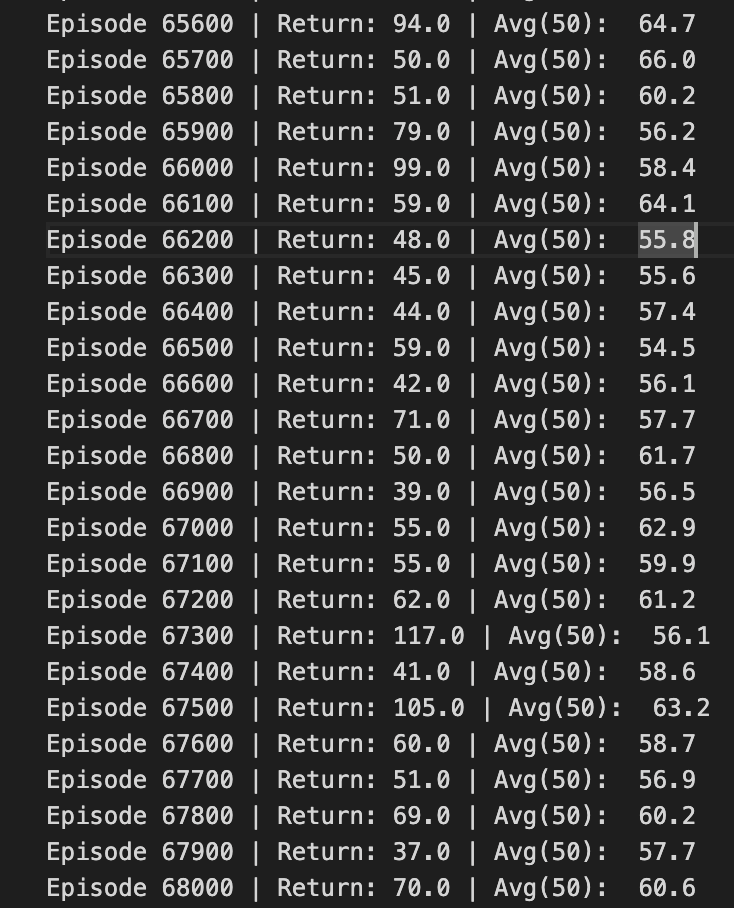

### 🔧 为什么要修改 `lr` 和 `num_episodes`？

上面这张训练日志的截图说明了问题:

- Episode 100: `Avg(50) = 22.5`
- Episode 62500: `Avg(50) = 46.1`

**跑了 6 万多局,平均回报只从 ~22 涨到 ~46,而且一直在 35~55 之间反复横跳,冲不上去。** CartPole 的回报上限是 500,正常收敛远不该这么慢。

#### 根本原因:学习率 `lr=1e-4` 太小
学习率决定每次参数更新迈的步子。`1e-4` 太小 → 每步只微调一点点 → 策略提升极慢,6 万局才走了一小段,还容易卡在平台期上不去。配合 `num_episodes=200000`(20 万局),就变成"跑很久但看不到明显进步"。

#### 修改方案
在参数单元格里改了两处(已标 `# 修改的地方`):

| 参数 | 原值 | 改后 | 原因 |
|------|------|------|------|
| `lr` | `1e-4` | `1e-3` | 步子放大 10 倍,策略提升更快,能冲出 40~50 的平台期 |
| `num_episodes` | `200000` | `3000` | CartPole 很简单,1000~2000 局通常就够收敛,不必跑 20 万 |

#### 重跑步骤(重要)
1. 先**停掉**当前训练(■);
2. 重新运行 **`PolicyNet` 单元格**——这会重置网络权重,从头开始学(否则会接着旧的卡住状态);
3. 运行改过的**参数单元格**;
4. 再运行训练单元格。

这样通常 1000~2000 局内 `Avg(50)` 就会明显往上冲、趋近 500,曲线和上面这张"卡住"的截图会完全不同。


### ✅ 为什么这个输出是对的？

运行训练后，你会看到打印的 `Avg(50)`（最近 50 个 episode 的平均回报）**整体呈上升趋势**，并逐渐逼近 CartPole-v1 的回报上限 **500**。这说明策略确实在学习。下面解释为什么这个结果是正确的、以及背后的原因。

#### 1. CartPole 的奖励结构决定了“回报 = 存活步数”
在 CartPole-v1 中，杆子每多撑住一步就 `+1` 奖励，倒下或越界就结束。所以一个 episode 的总回报 `ep_return` 就等于这一局坚持的步数。回报上升 = 杆子撑得越来越久 = 策略越来越好。这正是我们期望看到的现象。

#### 2. 策略网络（任务 1）的结构是正确的
- 输入是 4 维观测 `s ∈ ℝ⁴`，输出是 2 个动作的 **logits**；
- 用了两层隐藏层（128 → 64）+ ReLU，足够拟合这个简单任务；
- 输出层**不加激活**，直接交给 `Categorical(logits=...)`，由它在内部做 softmax 得到合法的概率分布 `π_θ(a|s)`。
这保证了 `dist.sample()` 采样动作、`dist.log_prob(a)` 计算 log 概率都是数学上正确的。

#### 3. 蒙特卡洛回报 Gₜ 的计算是正确的
代码从后往前递推：
$$G_t = r_t + \gamma\, G_{t+1}$$
这正是折扣回报的定义。`returns.insert(0, G)` 保证 `returns[t]` 对应时间步 t 的 $G_t$，和 `log_probs[t]` 一一对齐。

#### 4. 损失函数（任务 2）等价于策略梯度上升
REINFORCE 的目标是**最大化**期望回报：
$$\nabla_\theta J(\theta) = \mathbb{E}\big[\nabla_\theta \log \pi_\theta(a_t|s_t)\, G_t\big].$$
我们写的损失是
$$\text{loss} = -\sum_t \log \pi_\theta(a_t|s_t)\, G_t.$$
- 加 **负号** 是因为 PyTorch 优化器做的是梯度**下降**，而我们想做梯度**上升**，负号把两者对上；
- 对 loss 求导后正好得到 $-\nabla_\theta J$，所以 `optimizer.step()` 实际是在让 $J$ 增大；
- 直观理解：当 $G_t$ 大（好动作）时，最小化 loss 会**增大**该动作的 log 概率；当 $G_t$ 小/为负时，会**减小**它的概率——和我们想要的行为完全一致。

#### 5. 回报标准化让训练更稳定
`returns = (returns - mean) / (std + 1e-8)` 起到一个简单 **baseline** 的作用：把回报中心化到 0 附近，正的回报推高动作概率、负的压低。它**不改变梯度的期望方向**，但显著降低梯度方差，所以曲线上升得更平滑、更不容易发散。

#### 小结
输出正确的判据不是“某一局回报很高”，而是 **`Avg(50)` 随训练单调上升并趋近 500**。因为奖励结构、策略网络、回报计算、损失函数四个环节在数学上都自洽地对应着“让高回报动作更可能被选中”，所以平均回报上升就是算法正确工作的证据。
